<a href="https://colab.research.google.com/github/kykok18/PM_P2_RIZKY_FADILAH/blob/main/RegresiLinear_kelas5A_Kelompok3_rapi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-
"""RegresiLinear_kelas5A_Kelompok3.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1XvOrnEIB7Re850QgXQtvMM8OvPtZuXEI
"""


'RegresiLinear_kelas5A_Kelompok3.ipynb\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1XvOrnEIB7Re850QgXQtvMM8OvPtZuXEI\n'

In [3]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")


Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [4]:
# ---------------------------------------------------------
# 3. MENGUNDUH DATASET CONTOH
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
# ---------------------------------------------------------
print("Mengunduh dataset Medical Cost Personal ...")
!kaggle datasets download -d mirichoi0218/insurance

# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -q insurance.zip -d dataset_pasien/

print("Unduhan dan Ekstraksi Selesai!")


Mengunduh dataset Medical Cost Personal ...
Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 5.79MB/s]

Unduhan dan Ekstraksi Selesai!


In [5]:
# ---------------------------------------------------------
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
# ---------------------------------------------------------
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('dataset_pasien/insurance.csv')

# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil
print("\n--- 5 Baris Pertama Dataset Medical Cost Personal ---")
display(df.head())

# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())



--- 5 Baris Pertama Dataset Medical Cost Personal ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


--- 5 Baris Pertama Data ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- 5 Baris Terakhir Data ---


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



Dimensi dataset: 1338 baris, 7 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Daftar Nama Kolom ---
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))


--- Statistik Deskriptif untuk Kolom Numerik ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### Analisis Univariat untuk Kolom Numerik ###


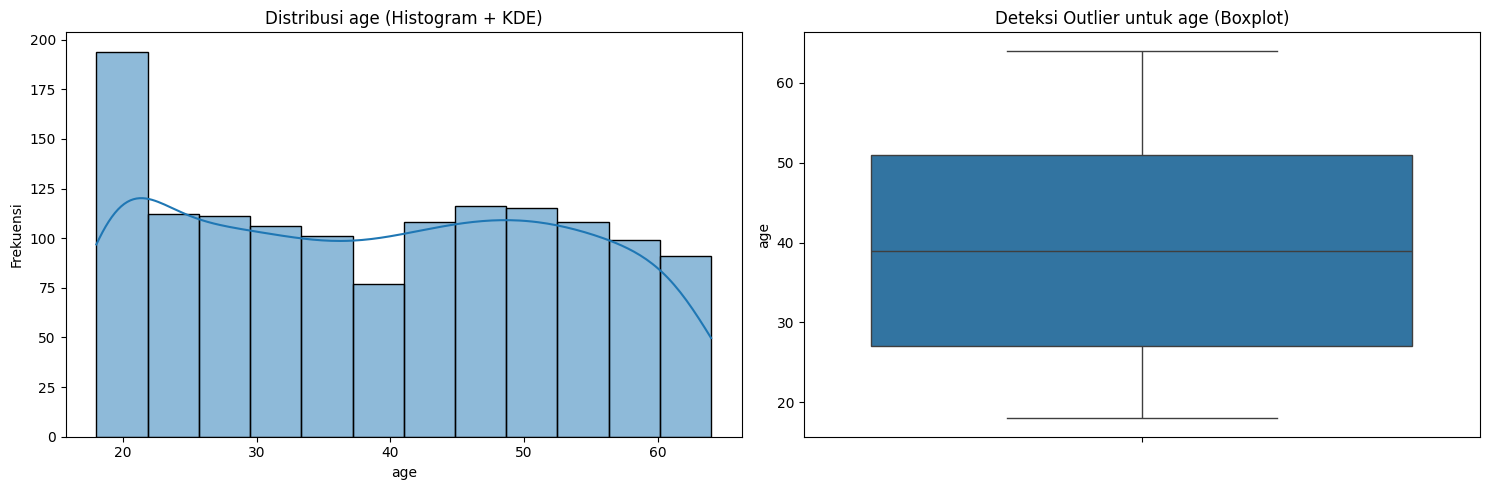

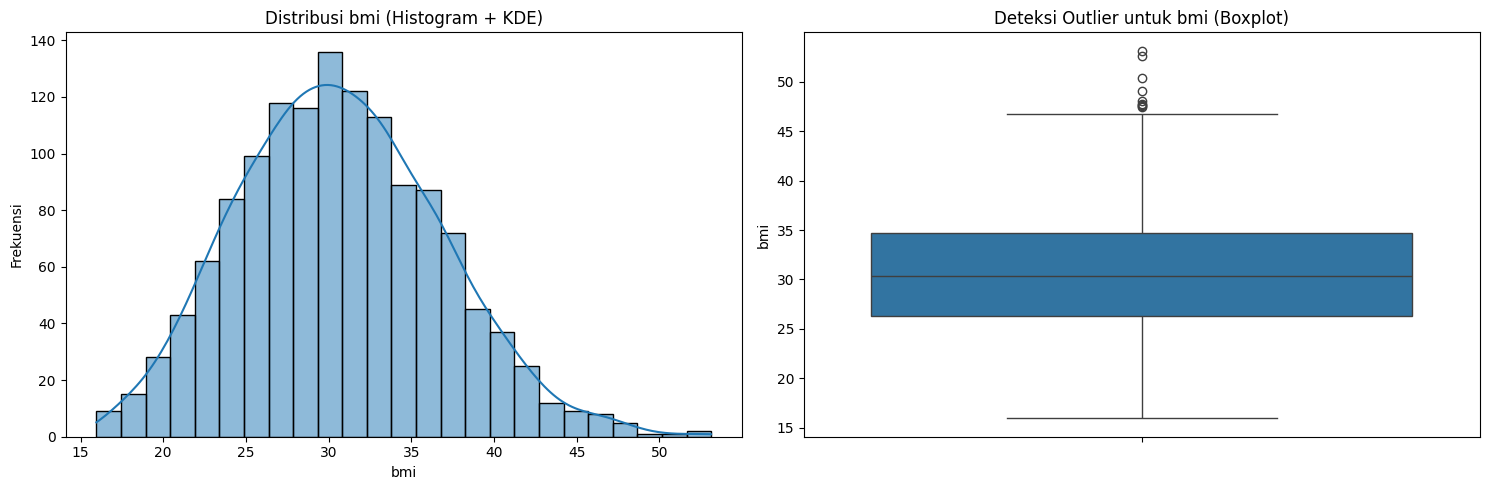

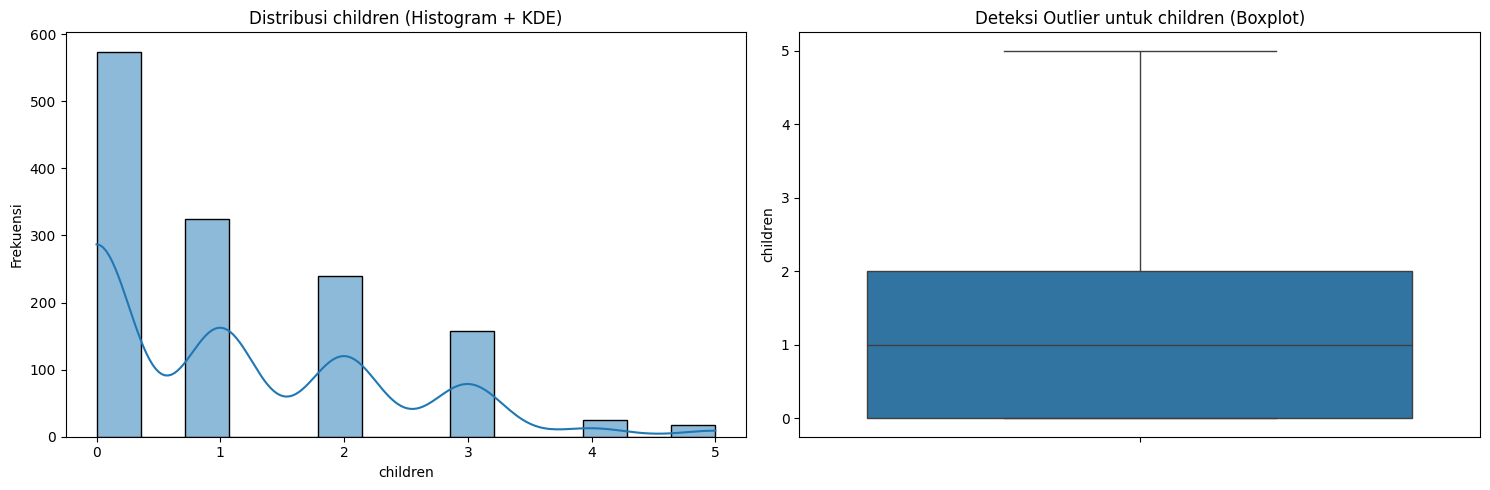

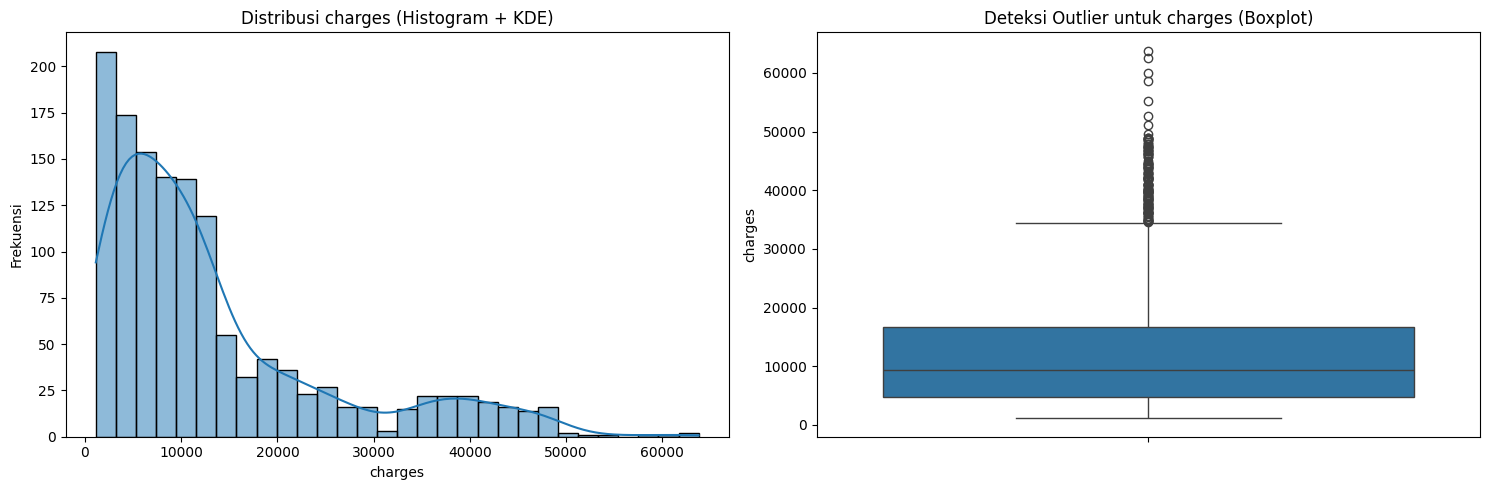


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_1397/3206953150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


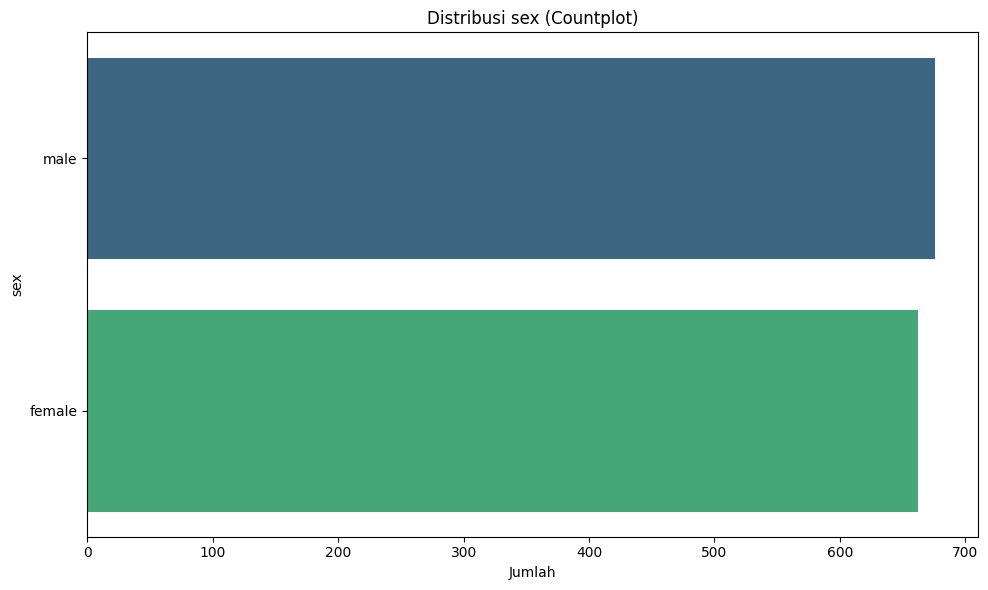

/tmp/ipykernel_1397/3206953150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


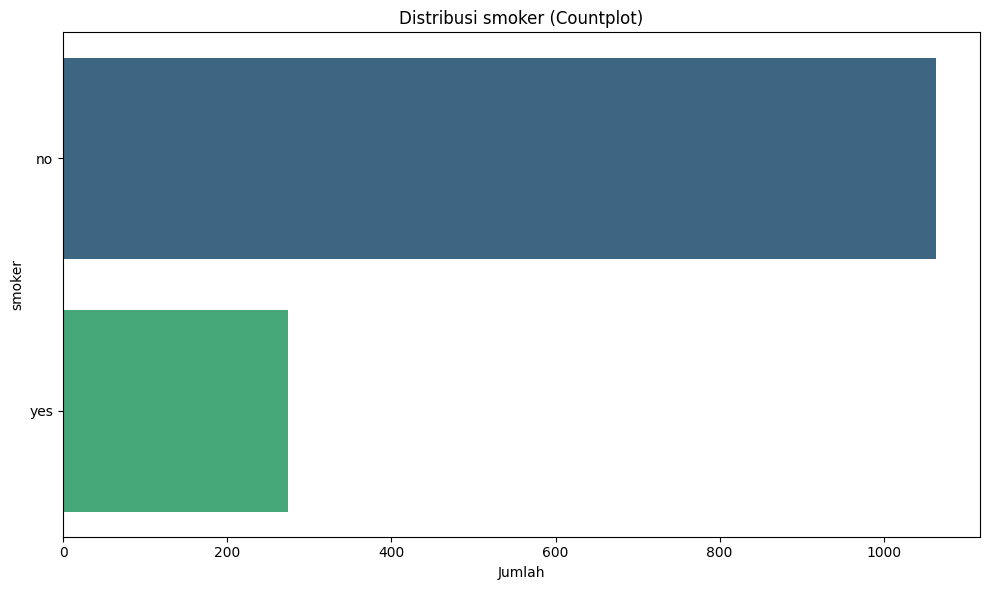

/tmp/ipykernel_1397/3206953150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


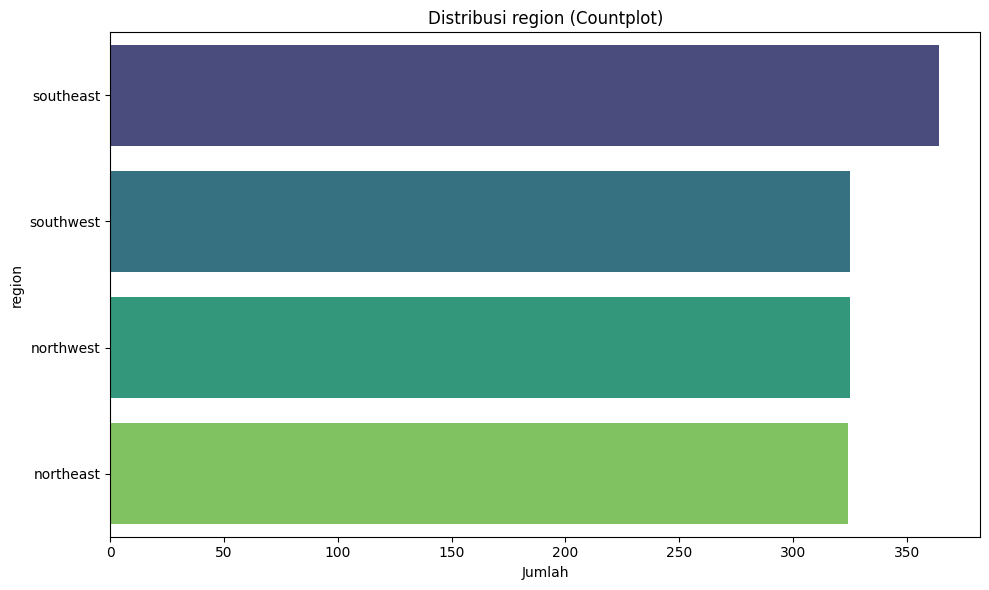

In [7]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


### 1. Heatmap Korelasi Antar Kolom Numerik ###


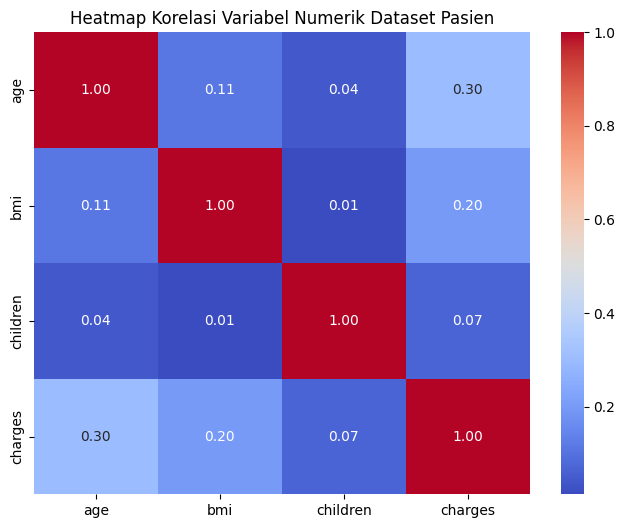


### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue) ###


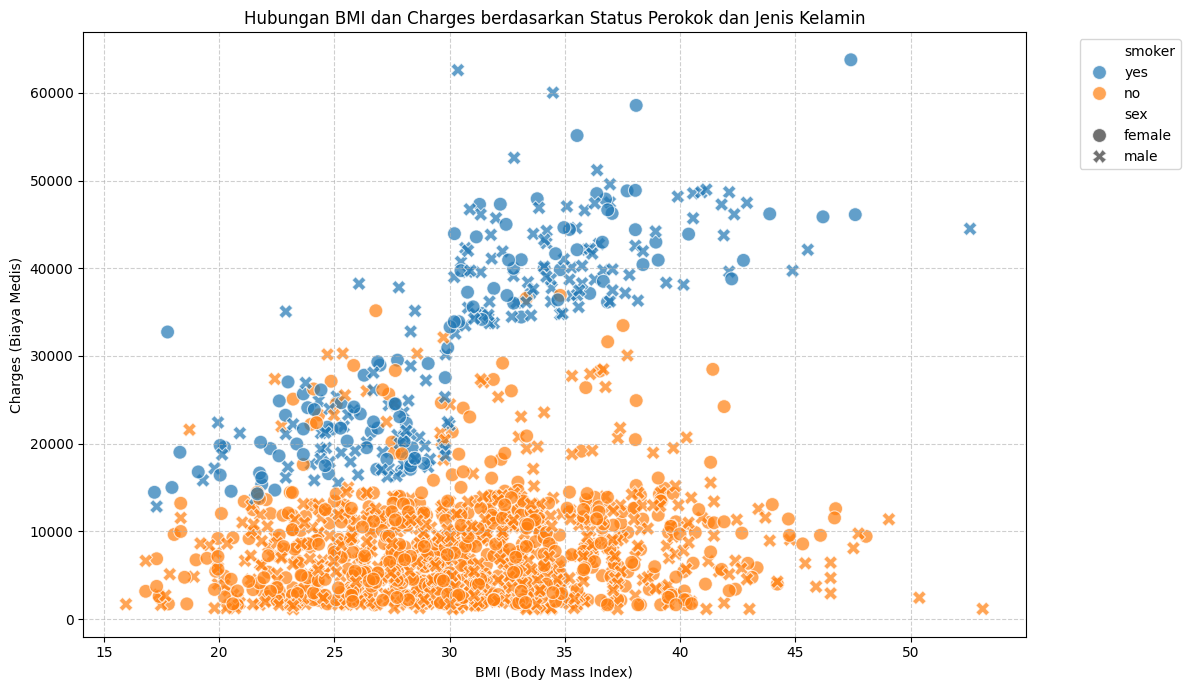

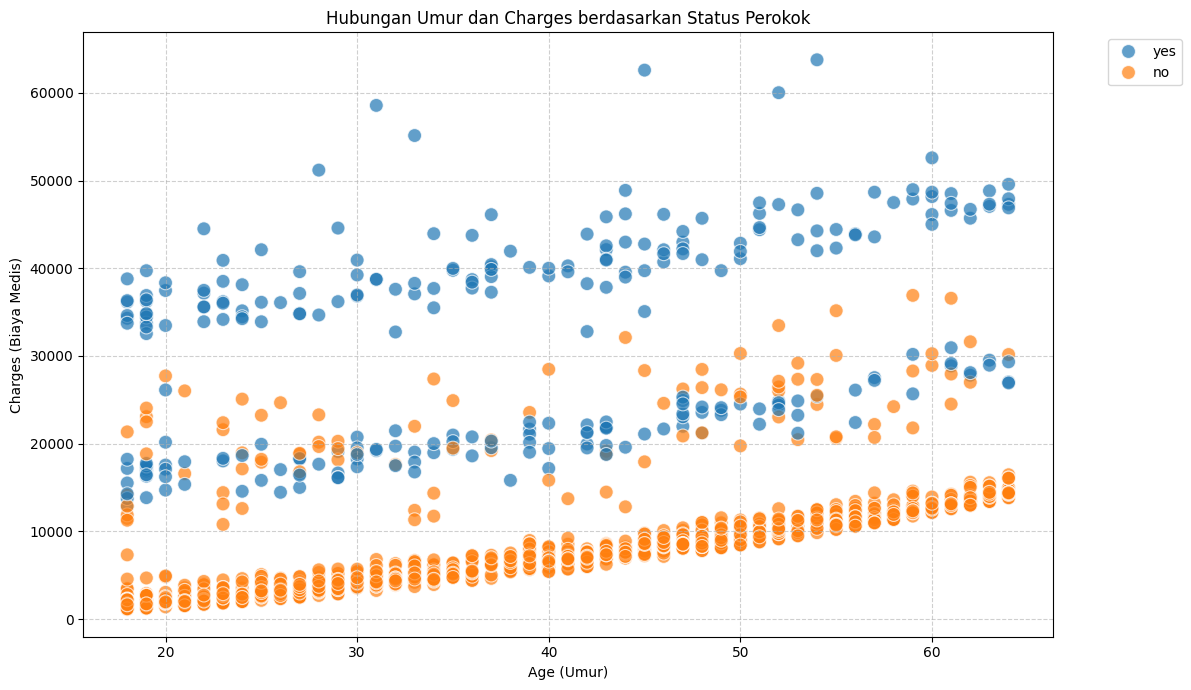


### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###


/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


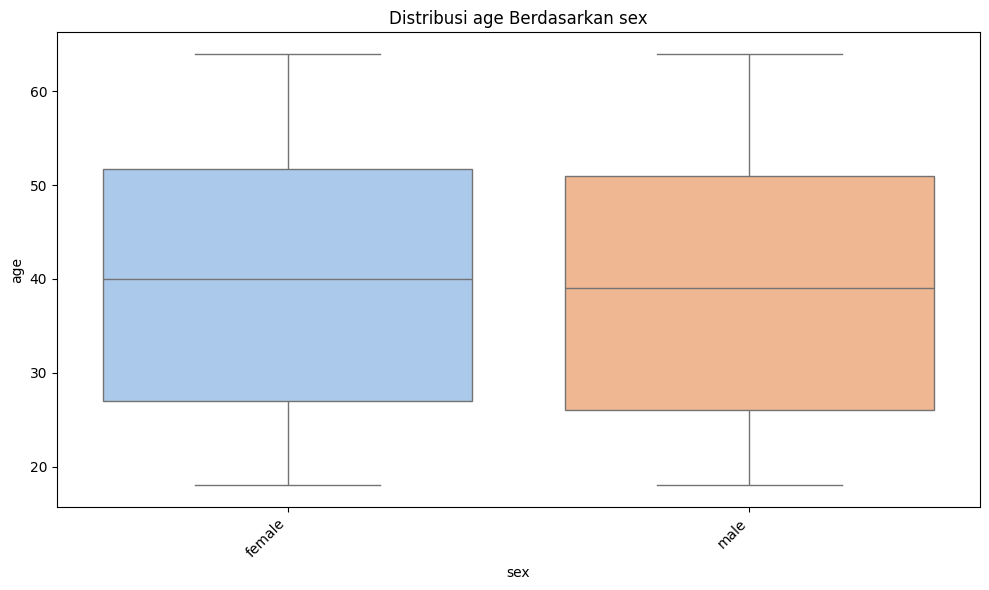

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


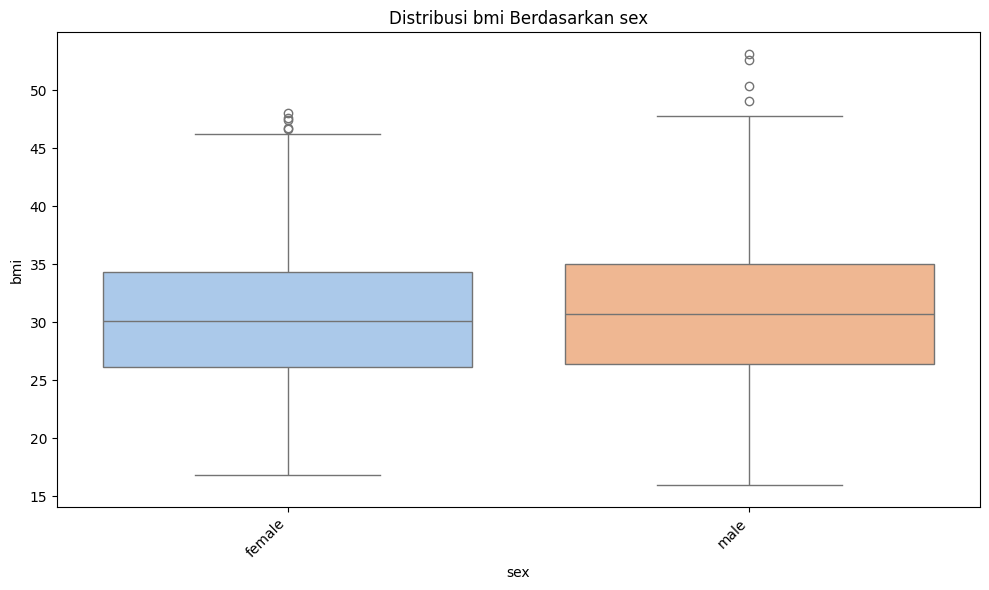

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


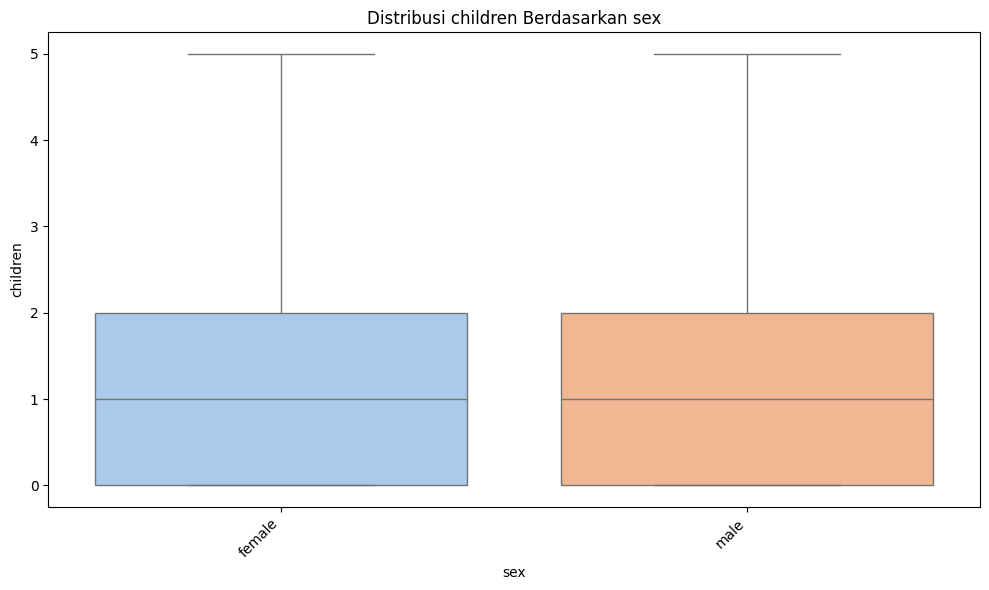

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


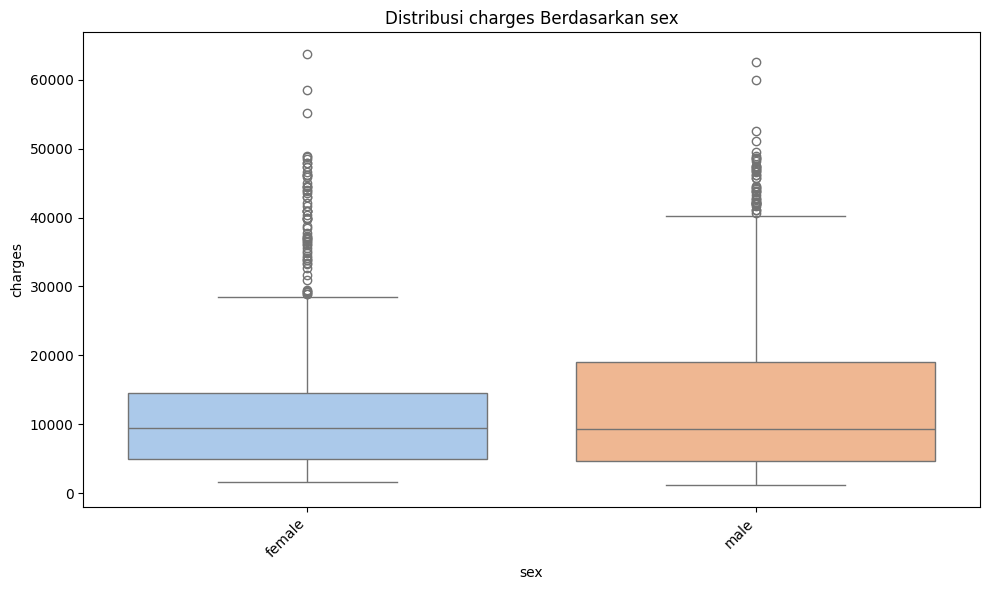

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


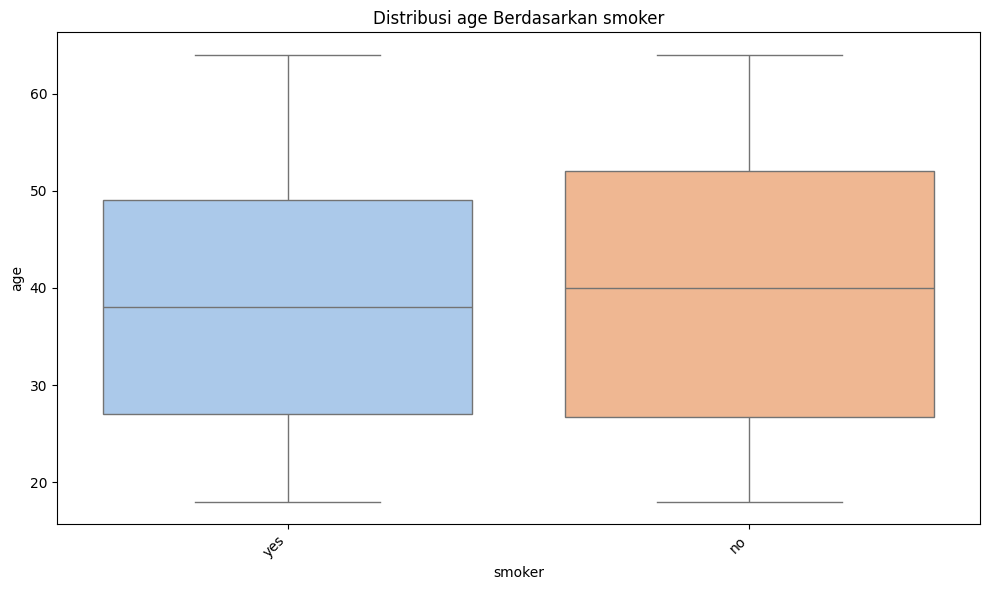

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


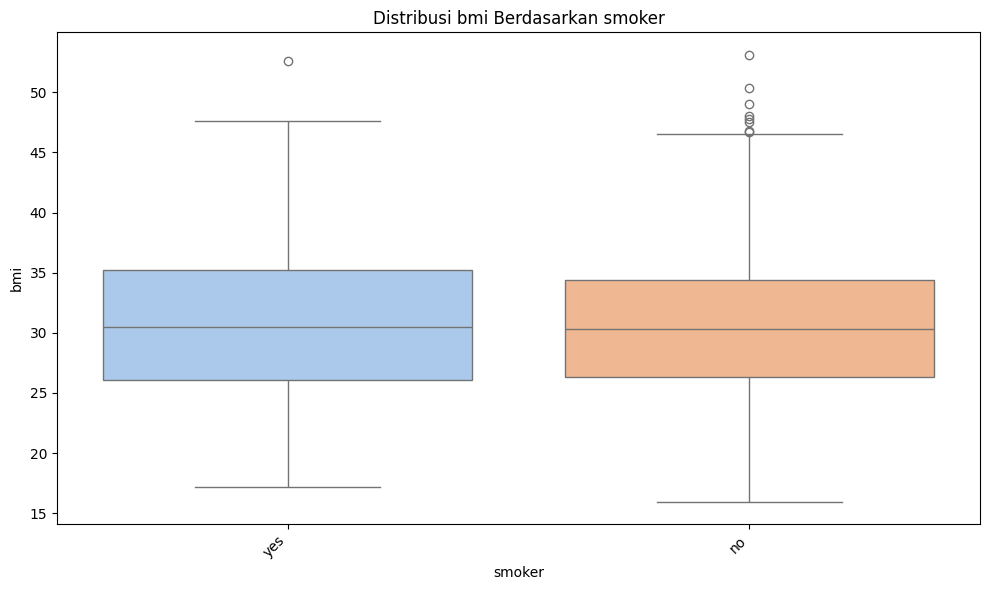

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


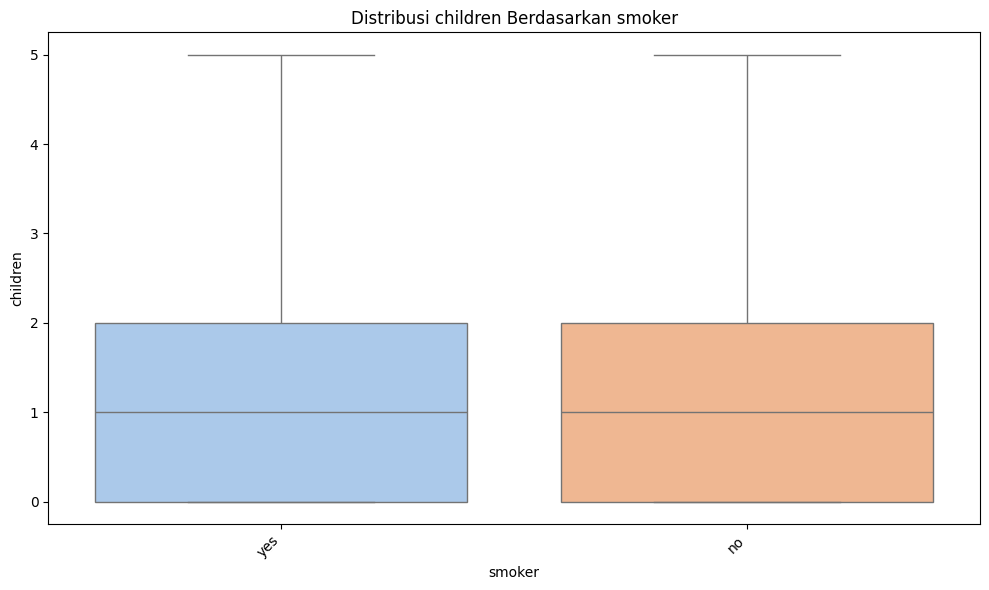

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


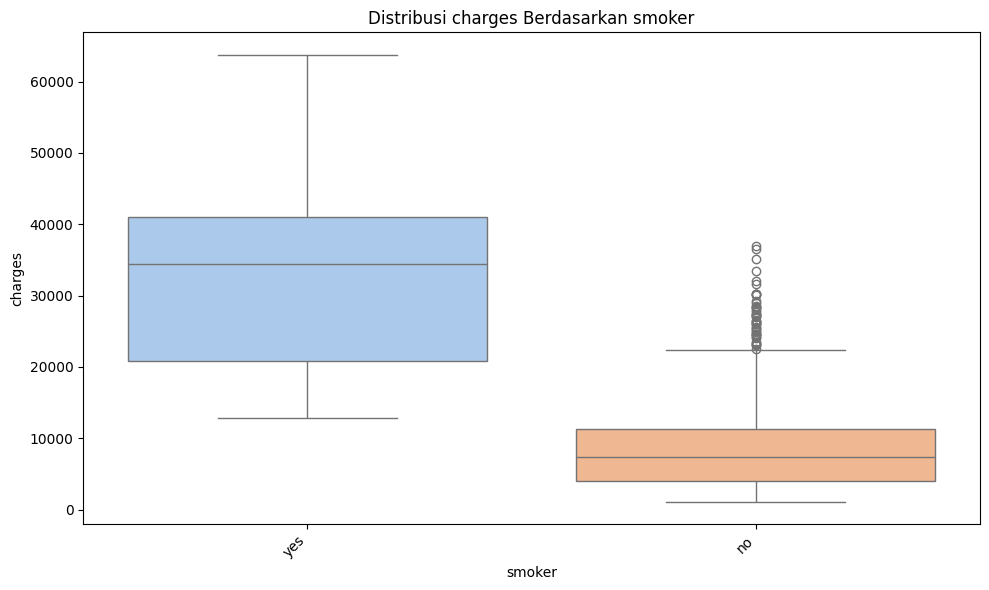

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


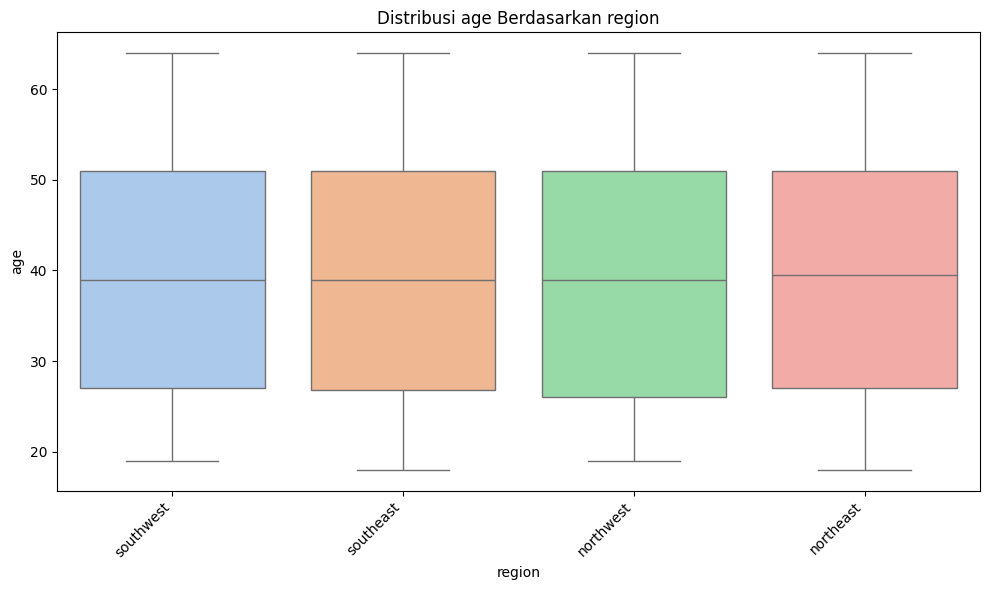

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


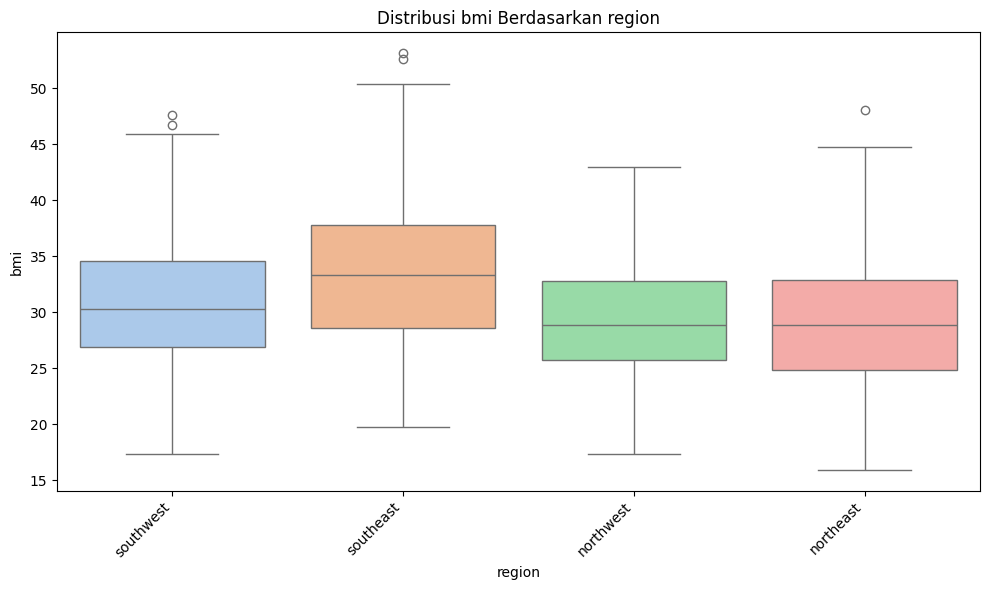

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


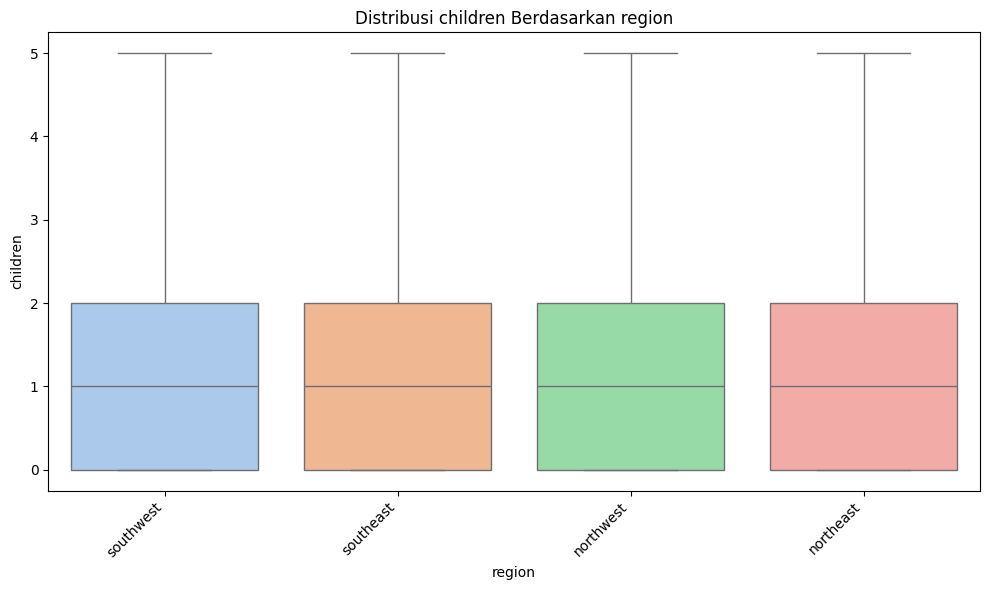

/tmp/ipykernel_1397/3149412365.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


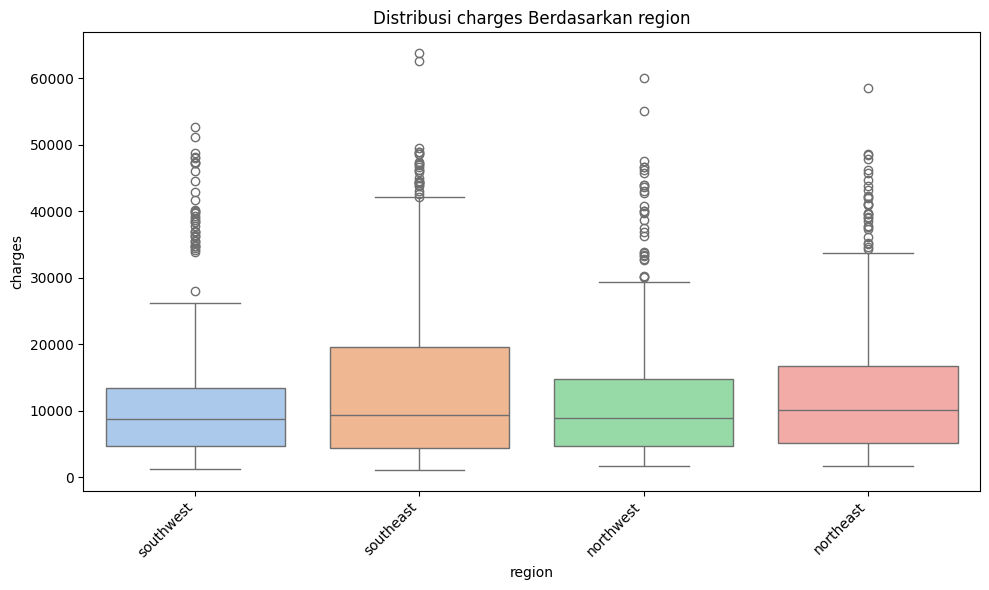

In [8]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(8, 6))
correlation_matrix = df[kolom_numerik].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik Dataset Pasien')
plt.show()

print("\n### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue) ###")
# Contoh: Hubungan BMI vs Charges, diwarnai berdasarkan status perokok ('smoker') dan dibedakan berdasarkan 'sex'
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='sex', s=100, alpha=0.7)
plt.title('Hubungan BMI dan Charges berdasarkan Status Perokok dan Jenis Kelamin')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Charges (Biaya Medis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Contoh lain: Hubungan Age vs Charges, diwarnai berdasarkan status perokok ('smoker')
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', s=100, alpha=0.7)
plt.title('Hubungan Umur dan Charges berdasarkan Status Perokok')
plt.xlabel('Age (Umur)')
plt.ylabel('Charges (Biaya Medis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###")
# Untuk setiap kolom kategorikal, bandingkan dengan setiap kolom numerik
for kat_kolom in kolom_kategorikal:
    for num_kolom in kolom_numerik:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')
        plt.title(f'Distribusi {num_kolom} Berdasarkan {kat_kolom}')
        plt.xlabel(kat_kolom)
        plt.ylabel(num_kolom)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


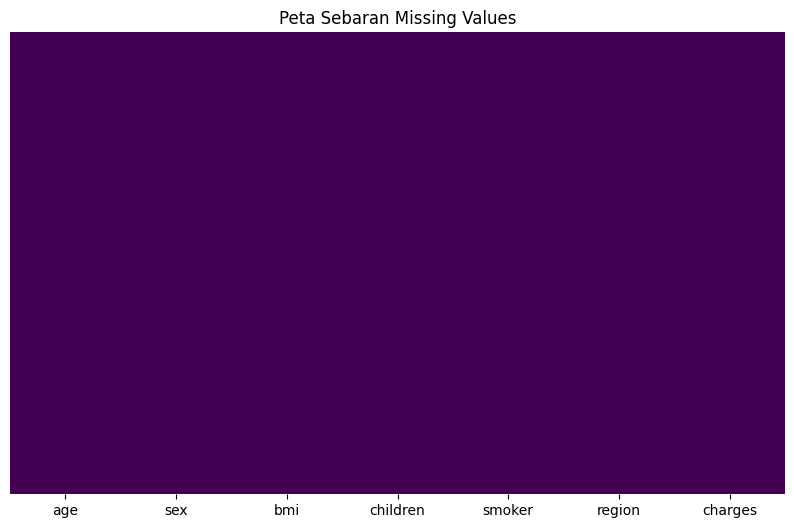


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 1
Dimensi data sebelum menghapus duplikat: (1338, 7)
Dimensi data setelah menghapus duplikat: (1337, 7)


In [9]:
print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
# Jika ada, Anda bisa menampilkan contoh duplikatnya dengan mengaktifkan baris di bawah:
# if jumlah_duplikat > 0:
#     display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

print(f"Dimensi data sebelum menghapus duplikat: {df.shape}")

# Menghapus baris duplikat dan mempertahankan baris pertama
df.drop_duplicates(inplace=True)

print(f"Dimensi data setelah menghapus duplikat: {df.shape}")


In [10]:
from sklearn.preprocessing import LabelEncoder

# Membuat salinan dataframe untuk preprocessing
df_encoded = df.copy()

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Daftar kolom kategorikal yang akan di-encode
kolom_kategori = ['sex', 'smoker', 'region']

# Menerapkan Label Encoding pada setiap kolom kategori
for col in kolom_kategori:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Mapping untuk kolom '{col}':")
    for index, class_label in enumerate(le.classes_):
        print(f"  {class_label} -> {index}")

print("\n--- 5 Baris Pertama Data Setelah Label Encoding ---")
display(df_encoded.head())


Mapping untuk kolom 'sex':
  female -> 0
  male -> 1
Mapping untuk kolom 'smoker':
  no -> 0
  yes -> 1
Mapping untuk kolom 'region':
  northeast -> 0
  northwest -> 1
  southeast -> 2
  southwest -> 3

--- 5 Baris Pertama Data Setelah Label Encoding ---


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [11]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Melakukan split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan dimensi hasil split
print("=== Pembagian Data Berhasil ===")
print(f"Jumlah data training (X_train): {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"Jumlah data testing (X_test): {X_test.shape[0]} baris, {X_test.shape[1]} kolom")
print(f"Jumlah label training (y_train): {y_train.shape[0]} baris")
print(f"Jumlah label testing (y_test): {y_test.shape[0]} baris")


=== Pembagian Data Berhasil ===
Jumlah data training (X_train): 1069 baris, 6 kolom
Jumlah data testing (X_test): 268 baris, 6 kolom
Jumlah label training (y_train): 1069 baris
Jumlah label testing (y_test): 268 baris


In [12]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Inisialisasi model Linear Regression
model = LinearRegression()

# Melatih model menggunakan data training
model.fit(X_train, y_train)

# Menampilkan intercept dan koefisien model
print("=== Pelatihan Model Linear Regression Selesai ===\n")
print(f"Intercept (Konstanta): {model.intercept_:.4f}")

# Membuat DataFrame untuk koefisien tiap fitur agar mudah dibaca
koefisien_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Koefisien': model.coef_
}).sort_values(by='Koefisien', ascending=False)

display(koefisien_df)


=== Pelatihan Model Linear Regression Selesai ===

Intercept (Konstanta): -11047.6866


,Fitur,Koefisien
4,smoker,23052.152752
3,children,534.120877
2,bmi,312.609045
0,age,248.764071
1,sex,-99.695394
5,region,-237.625147


=== HASIL EVALUASI MODEL LINEAR REGRESSION ===
Mean Absolute Error (MAE)   : 4,182.35
Mean Squared Error (MSE)     : 35,493,102.61
Root Mean Squared Error (RMSE): 5,957.61
R-squared (R2 Score)         : 0.8068 (80.68%)


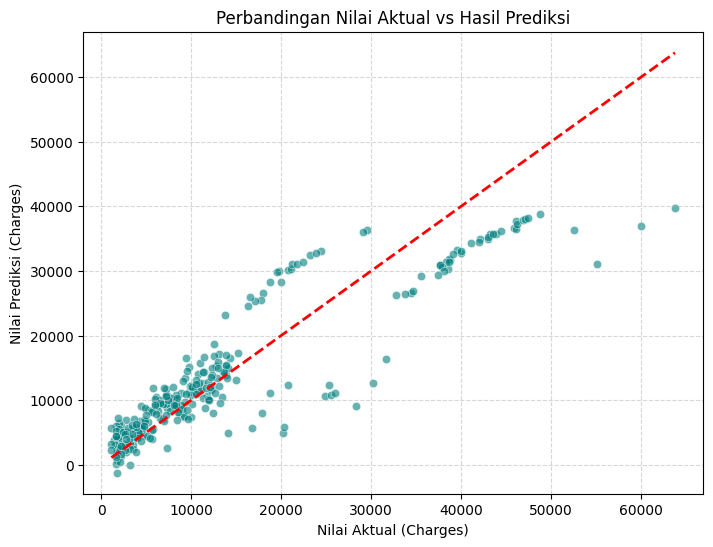

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# 2. Menghitung Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL LINEAR REGRESSION ===")
print(f"Mean Absolute Error (MAE)   : {mae:,.2f}" if mae > 0 else f"MAE: {mae:.4f}")
print(f"Mean Squared Error (MSE)     : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}" if rmse > 0 else f"RMSE: {rmse:.4f}")
print(f"R-squared (R2 Score)         : {r2:.4f} ({r2*100:.2f}%)")

# 3. Visualisasi Perbandingan Nilai Aktual vs Hasil Prediksi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
# Garis diagonal sempurna (Aktual = Prediksi)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Perbandingan Nilai Aktual vs Hasil Prediksi')
plt.xlabel('Nilai Aktual (Charges)')
plt.ylabel('Nilai Prediksi (Charges)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
